In [2]:
# ── CELDA 1: Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

In [3]:
# ── CELDA 2: Carga de datos ───────────────────────────────────────────────────
"""
Estrategia de features para clustering:
  Una fila por producto (referencia), columnas = estadísticos del precio
  a lo largo de los 154 días del histórico.

  No usamos precio de cada día como feature (154 columnas) porque:
  - Alta dimensionalidad → maldición de la dimensionalidad
  - K-Means con distancia euclidiana en 154 dims es poco fiable

  En su lugar usamos estadísticos descriptivos de la serie temporal:
  - precio_medio     : nivel de precio del producto
  - precio_std       : volatilidad del precio
  - precio_min/max   : rango absoluto
  - n_cambios        : número de veces que cambió de precio
  - variacion_media  : magnitud media de los cambios
  - dias_estable     : proporción de días sin cambio (estabilidad)
"""

IMG_DIR = Path("../docs/img/clustering")
IMG_DIR.mkdir(parents=True, exist_ok=True)
PARTITIONED_DIR = Path("../data/processed")

cols = ["referencia", "fecha", "precio_actual", "titulo",
        "categoria", "subcategoria", "marca_propia", "es_marca_propia"]

df = pd.read_parquet(PARTITIONED_DIR, columns=cols)
df["fecha"] = pd.to_datetime(df["fecha"].astype(str))
df = df.sort_values(["referencia", "fecha"]).reset_index(drop=True)

# Variación de precio día a día
df["precio_anterior"] = df.groupby("referencia")["precio_actual"].shift(1)
df["cambio"] = (df["precio_actual"] != df["precio_anterior"]) & df["precio_anterior"].notna()
df["variacion_abs"] = (df["precio_actual"] - df["precio_anterior"]).abs()

print(f"Datos: {len(df):,} filas | {df['referencia'].nunique():,} productos")

Datos: 694,446 filas | 5,042 productos


In [4]:
# ── CELDA 3: Feature engineering por producto ─────────────────────────────────
features_por_producto = df.groupby("referencia").agg(
    precio_medio     = ("precio_actual", "mean"),
    precio_std       = ("precio_actual", "std"),
    precio_min       = ("precio_actual", "min"),
    precio_max       = ("precio_actual", "max"),
    n_dias           = ("precio_actual", "count"),
    n_cambios        = ("cambio", "sum"),
    variacion_media  = ("variacion_abs", "mean"),
).reset_index()

# Features derivadas
features_por_producto["rango_precio"]   = (
    features_por_producto["precio_max"] - features_por_producto["precio_min"]
)
features_por_producto["cv_precio"] = (
    features_por_producto["precio_std"] / features_por_producto["precio_medio"]
).replace([np.inf, -np.inf], np.nan).fillna(0)
features_por_producto["prop_estable"]   = (           # proporción de días estable
    1 - features_por_producto["n_cambios"] / features_por_producto["n_dias"]
)
features_por_producto["variacion_media"] = (
    features_por_producto["variacion_media"].fillna(0)
)

# Añadir metadatos para interpretar los clusters
meta = df.groupby("referencia").agg(
    titulo       = ("titulo", "first"),
    categoria    = ("categoria", "first"),
    subcategoria = ("subcategoria", "first"),
    marca_propia = ("marca_propia", "first"),
    es_marca_propia = ("es_marca_propia", "first"),
).reset_index()

df_features = features_por_producto.merge(meta, on="referencia")

df_features["precio_std"] = df_features["precio_std"].fillna(0)

print(f"Features calculadas: {len(df_features):,} productos")
print(df_features[["precio_medio", "precio_std", "n_cambios",
                    "cv_precio", "prop_estable"]].describe())

Features calculadas: 5,042 productos
       precio_medio   precio_std    n_cambios    cv_precio  prop_estable
count   5042.000000  5042.000000  5042.000000  5042.000000   5042.000000
mean       3.819632     0.060958     1.347084     0.013555      0.989734
std       11.382064     0.414433     7.529122     0.029565      0.053094
min        0.164878     0.000000     0.000000     0.000000      0.238994
25%        1.522977     0.000000     0.000000     0.000000      0.993750
50%        2.362812     0.000000     0.000000     0.000000      1.000000
75%        3.959062     0.033942     1.000000     0.015106      1.000000
max      504.000000    25.000000   121.000000     0.387762      1.000000


In [5]:
# ── CELDA 4: Preparación para K-Means ────────────────────────────────────────
FEATURE_COLS = [
    "precio_medio",
    "precio_std",
    "rango_precio",
    "n_cambios",
    "cv_precio",
    "prop_estable",
    "variacion_media",
]

X = df_features[FEATURE_COLS].values

# Escalar — K-Means es sensible a la escala
# precio_medio (0-150€) dominaría sobre prop_estable (0-1) sin escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matrix X: {X_scaled.shape}")
print("Features escaladas — media≈0, std≈1 por columna")

Matrix X: (5042, 7)
Features escaladas — media≈0, std≈1 por columna


  K=2 | Inercia=23737.2 | Silhouette=0.987
  K=3 | Inercia=14834.1 | Silhouette=0.926
  K=4 | Inercia=10974.9 | Silhouette=0.762
  K=5 | Inercia=7552.1 | Silhouette=0.760
  K=6 | Inercia=6286.4 | Silhouette=0.756
  K=7 | Inercia=4951.5 | Silhouette=0.757
  K=8 | Inercia=3997.0 | Silhouette=0.702
  K=9 | Inercia=3538.6 | Silhouette=0.621
  K=10 | Inercia=3155.3 | Silhouette=0.619


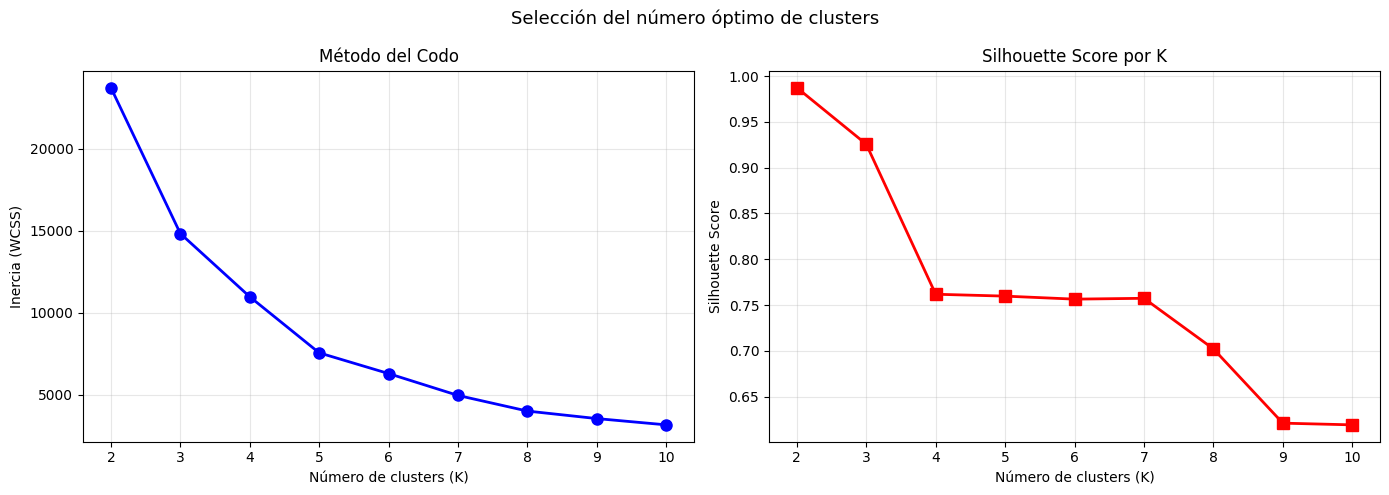


✅ K óptimo según Silhouette: 2


In [6]:
# ── CELDA 5: Método del codo para elegir K ────────────────────────────────────
"""
El método del codo calcula la inercia (suma de distancias al centroide)
para distintos valores de K. El "codo" — donde la curva deja de caer
abruptamente — indica el K óptimo.

Complementamos con el Silhouette Score: mide qué tan bien separados
están los clusters (1=perfecto, 0=solapados, -1=mal asignados).
Elegimos el K que maximiza el Silhouette Score.
"""
inercias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"  K={k} | Inercia={km.inertia_:.1f} | Silhouette={silhouettes[-1]:.3f}")

# Gráfica del codo + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inercias, "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del Codo")
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, "rs-", linewidth=2, markersize=8)
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por K")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Selección del número óptimo de clusters", fontsize=13)
plt.tight_layout()
plt.savefig(IMG_DIR / "codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

K_OPTIMO = K_range[silhouettes.index(max(silhouettes))]
print(f"\n✅ K óptimo según Silhouette: {K_OPTIMO}")

In [7]:
# ── CELDA 6: Entrenamiento final con K óptimo ─────────────────────────────────
K_FINAL = K_OPTIMO   # ajusta manualmente si el codo sugiere otro valor

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_features["cluster"] = km_final.fit_predict(X_scaled)

print(f"Clustering final con K={K_FINAL}")
print("\nDistribución de productos por cluster:")
print(df_features["cluster"].value_counts().sort_index())

Clustering final con K=2

Distribución de productos por cluster:
cluster
0    5041
1       1
Name: count, dtype: int64


In [8]:
# ── CELDA 7: Interpretación de clusters ──────────────────────────────────────
"""
Esta celda es la más importante para la memoria:
interpreta qué significa cada cluster en términos de negocio.
"""
resumen_clusters = df_features.groupby("cluster")[FEATURE_COLS].mean().round(3)
resumen_clusters["n_productos"] = df_features.groupby("cluster").size()
resumen_clusters["pct_marca_propia"] = (
    df_features.groupby("cluster")["es_marca_propia"].mean() * 100
).round(1)

print("Perfil medio por cluster:")
print(resumen_clusters.to_string())

# Top categorías por cluster
print("\nTop 3 categorías por cluster:")
for c in range(K_FINAL):
    top = (df_features[df_features["cluster"] == c]["categoria"]
           .value_counts().head(3))
    print(f"\n  Cluster {c}:")
    for cat, n in top.items():
        print(f"    {cat}: {n} productos")

Perfil medio por cluster:
         precio_medio  precio_std  rango_precio  n_cambios  cv_precio  prop_estable  variacion_media  n_productos  pct_marca_propia
cluster                                                                                                                            
0               3.773       0.056         0.155      1.347      0.014          0.99            0.004         5041              64.6
1             237.500      25.000        50.000      1.000      0.105          0.75           16.667            1               0.0

Top 3 categorías por cluster:

  Cluster 0:
    cuidado facial y corporal: 601 productos
    limpieza y hogar: 385 productos
    charcutería y quesos: 345 productos

  Cluster 1:
    charcutería y quesos: 1 productos


Varianza explicada: PC1=48.8%, PC2=27.0%, Total=75.8%


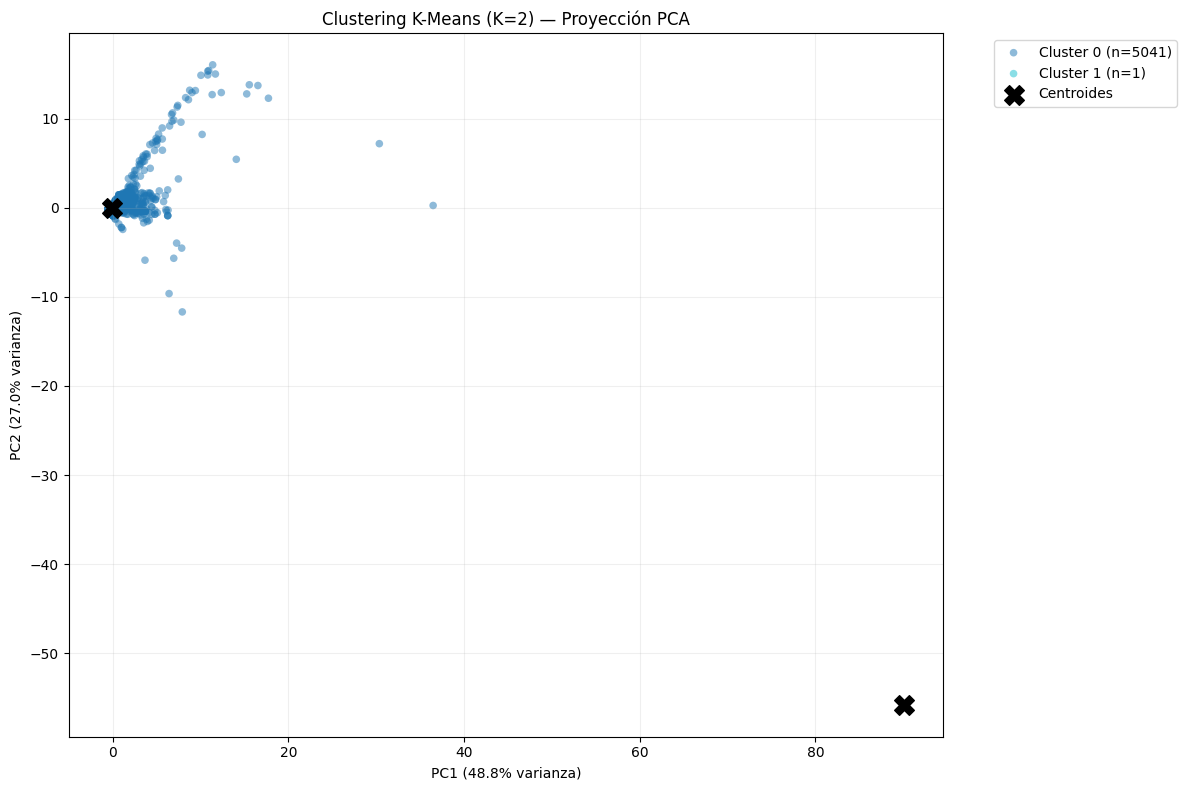

In [9]:
# ── CELDA 8: Visualización PCA 2D ────────────────────────────────────────────
"""
PCA reduce las 7 features a 2 dimensiones para visualizar los clusters.
No es perfecto (pierde información) pero permite ver la separación.
La varianza explicada indica cuánta información conservamos.
"""
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1={varianza[0]:.1%}, PC2={varianza[1]:.1%}, "
      f"Total={sum(varianza):.1%}")

fig, ax = plt.subplots(figsize=(12, 8))
colores = cm.tab10(np.linspace(0, 1, K_FINAL))

for c in range(K_FINAL):
    mask = df_features["cluster"] == c
    n    = mask.sum()
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colores[c]], label=f"Cluster {c} (n={n})",
        alpha=0.5, s=30, edgecolors="none"
    )

# Centroides en espacio PCA
centroides_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c="black", marker="X", s=200, zorder=5, label="Centroides")

ax.set_xlabel(f"PC1 ({varianza[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]:.1%} varianza)")
ax.set_title(f"Clustering K-Means (K={K_FINAL}) — Proyección PCA")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(IMG_DIR / "pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

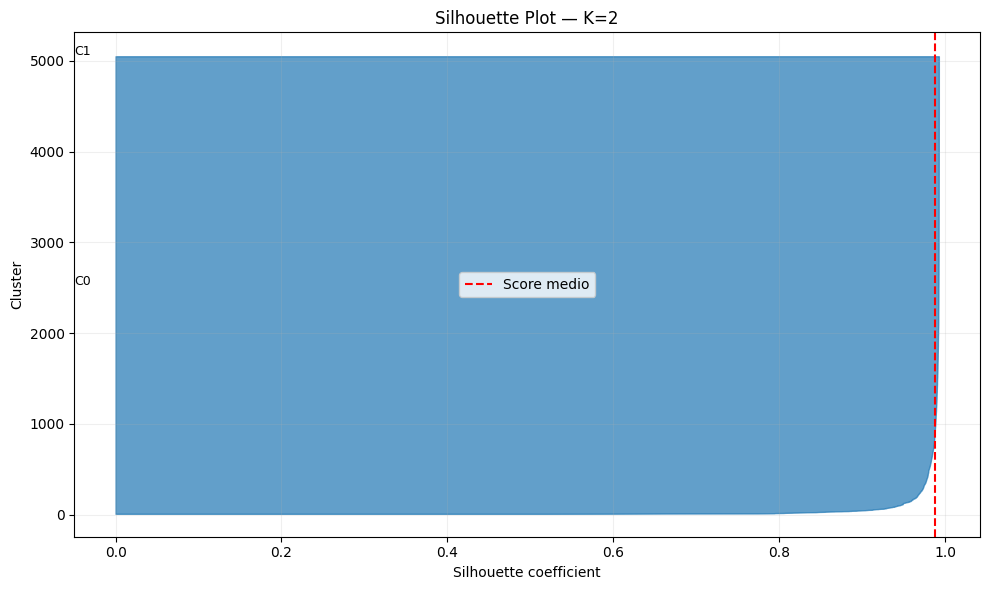

In [10]:
# ── CELDA 9: Silhouette plot por cluster ──────────────────────────────────────
"""
El Silhouette plot muestra la calidad de asignación de cada producto
a su cluster. Barras anchas y simétricas = clusters bien definidos.
"""
silhouette_vals = silhouette_samples(X_scaled, df_features["cluster"])
fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
for c in range(K_FINAL):
    vals_c = np.sort(silhouette_vals[df_features["cluster"] == c])
    size_c = len(vals_c)
    y_upper = y_lower + size_c

    color = colores[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_c,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size_c / 2, f"C{c}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, df_features["cluster"]),
           color="red", linestyle="--", label="Score medio")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — K={K_FINAL}")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(IMG_DIR / "silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── CELDA 10: Guardar resultados ──────────────────────────────────────────────
OUTPUT = Path("../data/clustering/kmeans_resultados.parquet")
OUTPUT.parent.mkdir(parents=True, exist_ok=True)

cols_guardar = ["referencia", "titulo", "categoria", "subcategoria",
                "marca_propia", "es_marca_propia", "cluster"] + FEATURE_COLS

df_features[cols_guardar].to_parquet(OUTPUT, index=False)
print(f"✅ Resultados guardados: {OUTPUT}")
print(f"   {len(df_features):,} productos con cluster asignado")

✅ Resultados guardados: ..\data\clustering\kmeans_resultados.parquet
   5,042 productos con cluster asignado
